# Fraud Risk Module: Rules and KRIs for Card Transactions

## Objective

This notebook documents the **Fraud Risk** workstream of the
*Enterprise Risk, Credit Risk, Liquidity Risk, and Fraud Analytics for Canadian Payments* project.

The goal is to:

- Use a synthetic card transaction dataset with an injected fraud label.
- Apply simple, interpretable fraud rules at the **card** level:
  - velocity rules (too many transactions in a short time window),
  - high-amount rules (unusually large transactions).
- Summarize results as **fraud KRIs** at both transaction and card level.
- Present the outputs in a way that reflects **second-line fraud risk oversight**.

## Business Problem

Payments fraud monitoring often starts with **rules** that flag unusual patterns such as:

- too many transactions on the same card within a short time window (velocity), and
- unusually large or out-of-pattern transaction amounts.

These rules support fraud prevention by:

- providing an interpretable first line of defense,
- generating alerts for investigation,
- and feeding into KRIs that help management understand fraud trends and the effectiveness of controls.

A second-line fraud risk function needs to understand not only whether fraud is being caught, but also at what **operational cost** (false positives) and how rules should be tuned or escalated.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-darkgrid")

tx_path = Path("../data/processed/fraud_transactions_with_rules.csv")
card_kri_path = Path("../outputs/fraud_card_kri_summary.csv")
portfolio_kri_path = Path("../outputs/fraud_portfolio_kri_overview.csv")

df_tx = pd.read_csv(tx_path, parse_dates=["timestamp"])
df_card = pd.read_csv(card_kri_path)
df_portfolio = pd.read_csv(portfolio_kri_path)

df_tx.head()

,transaction_id,card_id,timestamp,merchant_segment,channel,country,amount,fraud_pattern,is_fraud,rule_velocity,rule_high_amount,any_rule_hit
0,T0017347,C001137,2026-01-10 00:00:01,fuel,card_not_present,IN,43.83,NaN,False,False,False,False
1,T0016427,C002083,2026-01-10 00:00:01,marketplace,card_not_present,GB,42.83,NaN,False,False,False,False
2,T0020830,C000775,2026-01-10 00:00:02,gaming,card_present,CA,15.48,NaN,False,False,False,False
3,T0003486,C000068,2026-01-10 00:00:04,digital_content,card_present,BR,28.46,NaN,False,False,False,False
4,T0031385,C001704,2026-01-10 00:00:10,travel,card_not_present,FR,868.78,NaN,False,False,False,False


In [3]:
df_card.head()

,card_id,tx_count,total_amount,fraud_tx,velocity_hits,high_amount_hits,any_rule_hits,fraud_rate_card,rule_hit_rate,status
0,C000001,18,985.11,0,0,0,0,0.0,0.0,Low Risk
1,C000002,22,912.64,0,0,0,0,0.0,0.0,Low Risk
2,C000003,17,682.78,0,0,0,0,0.0,0.0,Low Risk
3,C000004,29,1620.39,0,0,0,0,0.0,0.0,Low Risk
4,C000005,13,1129.93,0,0,0,0,0.0,0.0,Low Risk


In [4]:
df_portfolio

,metric,value
0,total_transactions,50563.0000
1,total_fraud_transactions,563.0000
2,fraud_rate,0.0111
3,total_rule_hits,362.0000
4,rule_hit_rate,0.0072
5,fraud_captured_by_rules,351.0000
6,fraud_capture_rate,0.6234
7,fraud_not_flagged_by_rules,212.0000
8,rule_hits_not_fraud,11.0000


### Portfolio-Level KRI Interpretation

Key metrics from this synthetic portfolio include:

- **Total transactions** and **overall fraud rate**, which give a sense of the baseline fraud environment.
- **Total rule hits** and **rule hit rate**, which show how much of the portfolio is being touched by velocity and high-amount rules.
- **Fraud captured by rules** and **fraud capture rate**, which indicate how effective the rules are as a first line of defense.
- **Fraud not flagged by rules** and **rule hits not fraud**, which highlight residual fraud risk and potential false positives.

In a real setting, these KRIs would be monitored over time and compared against risk appetite and operational capacity.

In [5]:
total_tx = len(df_tx)
velocity_hits = df_tx["rule_velocity"].sum()
high_amount_hits = df_tx["rule_high_amount"].sum()

rule_rates = pd.DataFrame(
    {
        "rule": ["velocity", "high_amount"],
        "hit_count": [velocity_hits, high_amount_hits],
        "hit_rate": [velocity_hits / total_tx, high_amount_hits / total_tx],
    }
)

rule_rates

,rule,hit_count,hit_rate
0,velocity,228,0.004509
1,high_amount,134,0.002650


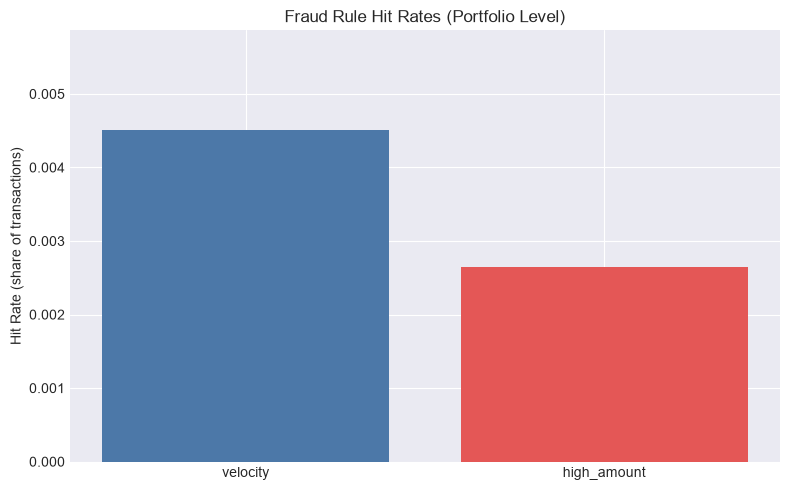

In [6]:
plt.figure(figsize=(8, 5))
plt.bar(
    rule_rates["rule"],
    rule_rates["hit_rate"],
    color=["#4C78A8", "#E45756"],
)
plt.ylabel("Hit Rate (share of transactions)")
plt.title("Fraud Rule Hit Rates (Portfolio Level)")
plt.ylim(0, max(rule_rates["hit_rate"]) * 1.3 if rule_rates["hit_rate"].max() > 0 else 1)
plt.tight_layout()
plt.show()

### Rule Hit Rate Interpretation

- The **velocity rule** measures how often cards exceed the transaction count threshold within the configured time window, consistent with industry velocity checks used to detect rapid abuse patterns.
- The **high-amount rule** measures how often transactions exceed a global high-value threshold, aligned with common practices of setting upper amount filters for high-risk payments.

The relative hit rates help indicate:

- whether rules are too tight (very high hit rates → high operational review load),
- too loose (very low hit rates → potential under-detection),
- or in a reasonable range for a first-line ruleset.

In [7]:
df_card[[
    "card_id",
    "tx_count",
    "fraud_tx",
    "velocity_hits",
    "high_amount_hits",
    "any_rule_hits",
    "fraud_rate_card",
    "rule_hit_rate",
    "status",
]].head(10)

,card_id,tx_count,fraud_tx,velocity_hits,high_amount_hits,any_rule_hits,fraud_rate_card,rule_hit_rate,status
0,C000001,18,0,0,0,0,0.0,0.0,Low Risk
1,C000002,22,0,0,0,0,0.0,0.0,Low Risk
2,C000003,17,0,0,0,0,0.0,0.0,Low Risk
3,C000004,29,0,0,0,0,0.0,0.0,Low Risk
4,C000005,13,0,0,0,0,0.0,0.0,Low Risk
5,C000006,16,0,0,0,0,0.0,0.0,Low Risk
6,C000007,18,0,0,0,0,0.0,0.0,Low Risk
7,C000008,27,0,0,0,0,0.0,0.0,Low Risk
8,C000009,16,0,0,0,0,0.0,0.0,Low Risk
9,C000010,28,0,0,0,0,0.0,0.0,Low Risk


In [8]:
top_cards = (
    df_card.sort_values(["any_rule_hits", "fraud_tx"], ascending=[False, False])
    .head(15)[["card_id", "tx_count", "fraud_tx", "any_rule_hits", "status"]]
)

top_cards

,card_id,tx_count,fraud_tx,any_rule_hits,status
468,C000469,52,24,17,High Risk (Fraud & Rules)
1762,C001763,51,24,17,High Risk (Fraud & Rules)
803,C000804,54,21,13,High Risk (Fraud & Rules)
2070,C002071,49,21,13,High Risk (Fraud & Rules)
1159,C001160,50,20,13,High Risk (Fraud & Rules)
1187,C001188,46,19,13,High Risk (Fraud & Rules)
1242,C001243,49,20,12,High Risk (Fraud & Rules)
1729,C001730,49,19,11,High Risk (Fraud & Rules)
2135,C002136,48,18,11,High Risk (Fraud & Rules)
2419,C002420,49,18,11,High Risk (Fraud & Rules)


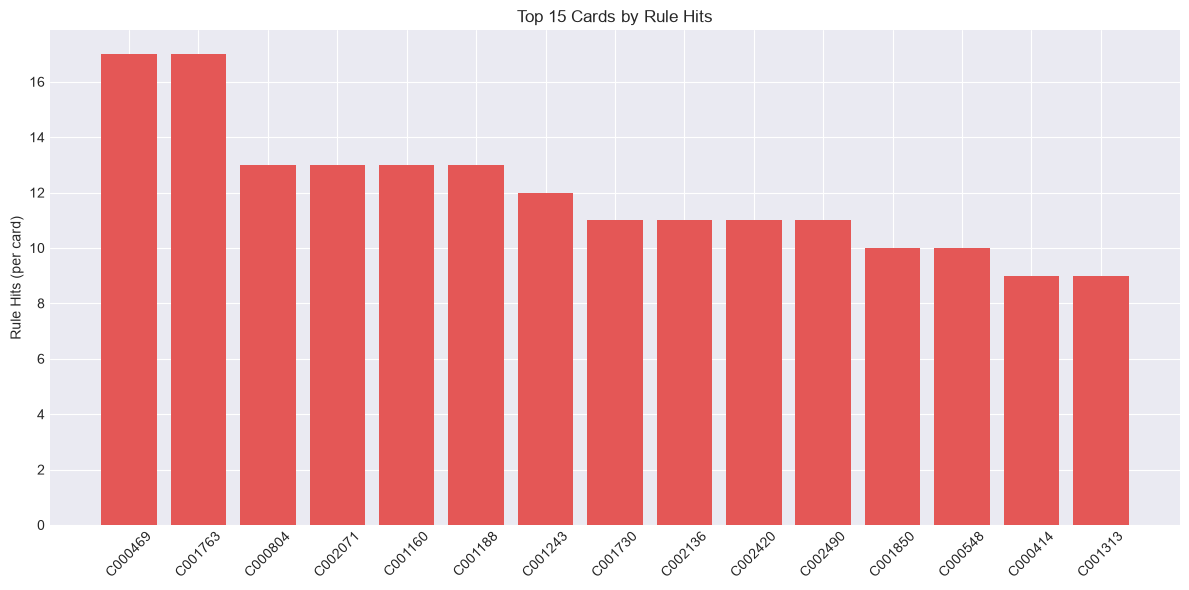

In [9]:
plt.figure(figsize=(12, 6))
colors = [
    "#E45756" if s.startswith("High") else "#F2A541" if s.startswith("Medium") else "#4C78A8"
    for s in top_cards["status"]
]

plt.bar(top_cards["card_id"], top_cards["any_rule_hits"], color=colors)
plt.xticks(rotation=45)
plt.ylabel("Rule Hits (per card)")
plt.title("Top 15 Cards by Rule Hits")
plt.tight_layout()
plt.show()

### Card-Level Risk Interpretation

- Cards with **High Risk (Fraud & Rules)** status have both synthetic fraud and rule hits. These represent clear investigation candidates and would likely be subject to blocking or additional verification.
- Cards with **Medium Risk (Rules Only)** status have rule hits but no confirmed fraud in this synthetic dataset. They are important for monitoring and potential dynamic controls, but some may turn out to be false positives.
- **Low Risk** cards show neither observed fraud nor rule hits and represent the broad benign population.

From a second-line standpoint, the distribution of cards across these statuses helps:

- prioritize investigative and operational resources,
- understand how rules are segmenting the population,
- and identify whether high-risk pockets are concentrated in particular segments, channels, or geographies.

In [10]:
# How much of the synthetic fraud is captured by rules?
fraud_and_rule = df_tx[(df_tx["is_fraud"]) & (df_tx["any_rule_hit"])].shape[0]
total_fraud = df_tx["is_fraud"].sum()
fraud_capture_rate = fraud_and_rule / total_fraud if total_fraud > 0 else None

# How many rule hits are not fraud?
rule_hits_not_fraud = df_tx[(~df_tx["is_fraud"]) & (df_tx["any_rule_hit"])].shape[0]
total_rule_hits = df_tx["any_rule_hit"].sum()
false_positive_rate = rule_hits_not_fraud / total_rule_hits if total_rule_hits > 0 else None

{
    "total_fraud": int(total_fraud),
    "fraud_captured_by_rules": int(fraud_and_rule),
    "fraud_capture_rate": round(fraud_capture_rate, 4) if fraud_capture_rate is not None else None,
    "rule_hits_not_fraud": int(rule_hits_not_fraud),
    "false_positive_rate_among_rule_hits": round(false_positive_rate, 4) if false_positive_rate is not None else None,
}

{'total_fraud': 563,
 'fraud_captured_by_rules': 351,
 'fraud_capture_rate': np.float64(0.6234),
 'rule_hits_not_fraud': 11,
 'false_positive_rate_among_rule_hits': np.float64(0.0304)}

### Rule Effectiveness and False Positives

Key observations:

- **Fraud capture rate** (fraction of fraud transactions that are flagged by rules) provides a measure of rule **effectiveness**.
- **False positive rate among rule hits** (share of alerts that are not fraud) provides a measure of rule **efficiency**.

Second-line fraud risk oversight would use these metrics to:

- Assess whether current rules are strong enough as a first line of defense.
- Identify where additional controls or tuning are needed to reduce operational review load.
- Decide when more advanced techniques (e.g., risk scoring or machine learning) are justified on top of the rules.

## Second-Line Fraud Risk Interpretation

From an ERM perspective, the value of this rules-based module is that it:

- Provides a transparent, explainable **ruleset** (velocity and high-amount) that can be challenged and tuned.
- Produces portfolio-level **KRIs** (fraud rate, rule hit rate, fraud capture, false positives) that can be monitored over time.
- Identifies **high-risk cards** for focus and escalation, linking rules and outcomes (fraud labels).

In an interview or governance setting, this module supports a narrative that you:

- understand practical **fraud controls** used in payments (velocity checks, amount filters),
- can translate them into **data and KRIs**,
- and can articulate the trade-offs between fraud prevention, customer experience, and operational workload.

## Limitations and Next Steps

**Limitations:**

- Data, rules, and labels are synthetic and simplified.
- Rules use global thresholds; in production, thresholds would be segment-specific and regularly tuned.
- Only a small set of rule types is implemented; real programs use many more signals and contextual checks.

**Next Steps:**

- Add additional rules (e.g., country mismatch, high-risk merchant segments, time-of-day anomalies).
- Introduce a simple **risk scoring** approach that aggregates rule hits into a score.
- Explore a light machine learning model as a challenger, focusing on explainability rather than black-box performance.
- Integrate fraud KRIs into the portfolio-wide ERM dashboard alongside credit, liquidity, and other risk measures.